In [83]:
import pandas as pd
import seaborn as sns

In [84]:
sns.set_theme(style="darkgrid")
sns.set_palette("viridis")

In [85]:
df = pd.read_csv("data/raw/Telco-Customer-Churn.csv")

Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The data set includes information about:

* Customers who left within the last month – the column is called Churn
* Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
* Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
* Demographic info about customers – gender, age range, and if they have partners and dependents


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [87]:
to_drop = ["customerID"]

In [88]:
df.groupby("gender")["Churn"].value_counts(normalize=True)

gender  Churn
Female  No       0.730791
        Yes      0.269209
Male    No       0.738397
        Yes      0.261603
Name: proportion, dtype: float64

In [89]:
to_drop.append("gender")

In [90]:
print(df.SeniorCitizen.value_counts())
df.groupby("SeniorCitizen")["Churn"].value_counts(normalize=True)

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


SeniorCitizen  Churn
0              No       0.763938
               Yes      0.236062
1              No       0.583187
               Yes      0.416813
Name: proportion, dtype: float64

In [91]:
print(df.Partner.value_counts())
df.groupby("Partner")["Churn"].value_counts(normalize=True)


Partner
No     3641
Yes    3402
Name: count, dtype: int64


Partner  Churn
No       No       0.670420
         Yes      0.329580
Yes      No       0.803351
         Yes      0.196649
Name: proportion, dtype: float64

In [92]:
df["Partner"] = df["Partner"].map({"Yes": 1, "No": 0}).astype(int)

In [93]:
print(df.Dependents.value_counts())
df.groupby("Dependents")["Churn"].value_counts(normalize=True)

Dependents
No     4933
Yes    2110
Name: count, dtype: int64


Dependents  Churn
No          No       0.687209
            Yes      0.312791
Yes         No       0.845498
            Yes      0.154502
Name: proportion, dtype: float64

In [94]:
df["Dependents"] = df["Dependents"].map({"Yes": 1, "No": 0}).astype(int)

In [95]:
df.query("Dependents == 1 and Partner == 0").Churn.value_counts(normalize=True)

Churn
No     0.786704
Yes    0.213296
Name: proportion, dtype: float64

In [96]:
df.query("Dependents == 0 and Partner == 1").Churn.value_counts(normalize=True)


Churn
No     0.745917
Yes    0.254083
Name: proportion, dtype: float64

In [97]:
df.query("Dependents == 1 and Partner == 1").Churn.value_counts(normalize=True)

Churn
No     0.857633
Yes    0.142367
Name: proportion, dtype: float64

In [98]:
df.loc[:, "family_score"] = df["Dependents"] + df["Partner"]
df.groupby("family_score")["Churn"].value_counts(normalize=True)


family_score  Churn
0             No       0.657622
              Yes      0.342378
1             No       0.753227
              Yes      0.246773
2             No       0.857633
              Yes      0.142367
Name: proportion, dtype: float64

In [99]:
to_drop.append("Partner")
to_drop.append("Dependents")

In [100]:
df.tenure.describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [101]:
# for new customers that havent completed one month of tenure
df.loc[df["tenure"] == 0, "TotalCharges"] = df.loc[df["tenure"] == 0, "MonthlyCharges"]
df.loc[df["tenure"] == 0, "tenure"] = df.loc[df["tenure"] == 0, "tenure"] + 1

In [102]:
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [103]:
def inspect(feature: str):
    print(df[feature].value_counts())
    print("------------------------------")
    print(df.groupby(feature)["Churn"].value_counts(normalize=True))

In [104]:
inspect("PhoneService")

PhoneService
Yes    6361
No      682
Name: count, dtype: int64
------------------------------
PhoneService  Churn
No            No       0.750733
              Yes      0.249267
Yes           No       0.732904
              Yes      0.267096
Name: proportion, dtype: float64


In [105]:
df["PhoneService"] = df["PhoneService"].map({"Yes": 1, "No": 0}).astype(int)

In [106]:
inspect("MultipleLines")

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
------------------------------
MultipleLines     Churn
No                No       0.749558
                  Yes      0.250442
No phone service  No       0.750733
                  Yes      0.249267
Yes               No       0.713901
                  Yes      0.286099
Name: proportion, dtype: float64


In [107]:
df["MultipleLines"] = (
    df["MultipleLines"].map({"Yes": 1, "No": 0, "No phone service": 0}).astype(int)
)


In [108]:
df["Phone_service_score"] = df["PhoneService"] + df["MultipleLines"]

In [109]:
inspect("Phone_service_score")

Phone_service_score
1    3390
2    2971
0     682
Name: count, dtype: int64
------------------------------
Phone_service_score  Churn
0                    No       0.750733
                     Yes      0.249267
1                    No       0.749558
                     Yes      0.250442
2                    No       0.713901
                     Yes      0.286099
Name: proportion, dtype: float64


In [110]:
to_drop.append("PhoneService")
to_drop.append("MultipleLines")
to_drop.append("Phone_service_score")

In [111]:
inspect("InternetService")

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
------------------------------
InternetService  Churn
DSL              No       0.810409
                 Yes      0.189591
Fiber optic      No       0.581072
                 Yes      0.418928
No               No       0.925950
                 Yes      0.074050
Name: proportion, dtype: float64


In [112]:
df["InternetService"] = (
    df["InternetService"]
    .map(
        {
            "Fiber optic": 2,
            "DSL": 1,
            "No": 0,
        }
    )
    .astype(int)
)

In [113]:
inspect("OnlineSecurity")

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
------------------------------
OnlineSecurity       Churn
No                   No       0.582333
                     Yes      0.417667
No internet service  No       0.925950
                     Yes      0.074050
Yes                  No       0.853888
                     Yes      0.146112
Name: proportion, dtype: float64


In [114]:
df["OnlineSecurity"] = (
    df["OnlineSecurity"]
    .map(
        {
            "Yes": 1,
            "No internet service": -0.25,
            "No": 0,
        }
    )
    .astype(float)
)

In [115]:
inspect("OnlineBackup")

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
------------------------------
OnlineBackup         Churn
No                   No       0.600712
                     Yes      0.399288
No internet service  No       0.925950
                     Yes      0.074050
Yes                  No       0.784685
                     Yes      0.215315
Name: proportion, dtype: float64


In [116]:
df["OnlineBackup"] = (
    df["OnlineBackup"]
    .map(
        {
            "Yes": 1,
            "No internet service": -0.25,
            "No": 0,
        }
    )
    .astype(float)
)

In [117]:
inspect("DeviceProtection")

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
------------------------------
DeviceProtection     Churn
No                   No       0.608724
                     Yes      0.391276
No internet service  No       0.925950
                     Yes      0.074050
Yes                  No       0.774979
                     Yes      0.225021
Name: proportion, dtype: float64


In [118]:
df["DeviceProtection"] = (
    df["DeviceProtection"]
    .map(
        {
            "Yes": 1,
            "No internet service": -0.25,
            "No": 0,
        }
    )
    .astype(float)
)

In [119]:
inspect("TechSupport")

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64
------------------------------
TechSupport          Churn
No                   No       0.583645
                     Yes      0.416355
No internet service  No       0.925950
                     Yes      0.074050
Yes                  No       0.848337
                     Yes      0.151663
Name: proportion, dtype: float64


In [120]:
df["TechSupport"] = (
    df["TechSupport"]
    .map(
        {
            "Yes": 1,
            "No internet service": -0.25,
            "No": 0,
        }
    )
    .astype(float)
)

In [121]:
df["Internet_service_score"] = (
    df["TechSupport"]
    + df["DeviceProtection"]
    + df["OnlineBackup"]
    + df["OnlineSecurity"]
)

In [122]:
inspect("Internet_service_score")

Internet_service_score
-1.0    1526
 1.0    1467
 2.0    1372
 0.0    1267
 3.0     941
 4.0     470
Name: count, dtype: int64
------------------------------
Internet_service_score  Churn
-1.0                    No       0.925950
                        Yes      0.074050
 0.0                    Yes      0.566693
                        No       0.433307
 1.0                    No       0.611452
                        Yes      0.388548
 2.0                    No       0.762391
                        Yes      0.237609
 3.0                    No       0.875664
                        Yes      0.124336
 4.0                    No       0.946809
                        Yes      0.053191
Name: proportion, dtype: float64


In [123]:
to_drop.append("TechSupport")
to_drop.append("DeviceProtection")
to_drop.append("OnlineSecurity")
to_drop.append("OnlineBackup")

In [124]:
df.query("InternetService == 2 and Internet_service_score == 0").Churn.value_counts(
    normalize=True
)

Churn
Yes    0.635613
No     0.364387
Name: proportion, dtype: float64

In [125]:
inspect("StreamingTV")

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64
------------------------------
StreamingTV          Churn
No                   No       0.664769
                     Yes      0.335231
No internet service  No       0.925950
                     Yes      0.074050
Yes                  No       0.699298
                     Yes      0.300702
Name: proportion, dtype: float64


In [126]:
to_drop.append("StreamingTV")

In [127]:
inspect("StreamingMovies")

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64
------------------------------
StreamingMovies      Churn
No                   No       0.663196
                     Yes      0.336804
No internet service  No       0.925950
                     Yes      0.074050
Yes                  No       0.700586
                     Yes      0.299414
Name: proportion, dtype: float64


In [128]:
to_drop.append("StreamingMovies")

In [129]:
inspect("Contract")

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
------------------------------
Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64


In [130]:
df["Contract"] = (
    df["Contract"].map({"Month-to-month": 0, "One year": 1, "Two year": 2}).astype(int)
)

In [131]:
inspect("PaperlessBilling")

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64
------------------------------
PaperlessBilling  Churn
No                No       0.836699
                  Yes      0.163301
Yes               No       0.664349
                  Yes      0.335651
Name: proportion, dtype: float64


In [132]:
df["PaperlessBilling"] = df["PaperlessBilling"].map({"Yes": 1, "No": 0}).astype(int)

In [133]:
inspect("PaymentMethod")

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64
------------------------------
PaymentMethod              Churn
Bank transfer (automatic)  No       0.832902
                           Yes      0.167098
Credit card (automatic)    No       0.847569
                           Yes      0.152431
Electronic check           No       0.547146
                           Yes      0.452854
Mailed check               No       0.808933
                           Yes      0.191067
Name: proportion, dtype: float64


In [134]:
df["Payment_Electronic_check"] = (df["PaymentMethod"] == "Electronic check").astype(int)

In [135]:
to_drop.append("PaymentMethod")

In [136]:
df.Churn.value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [137]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0}).astype(int)

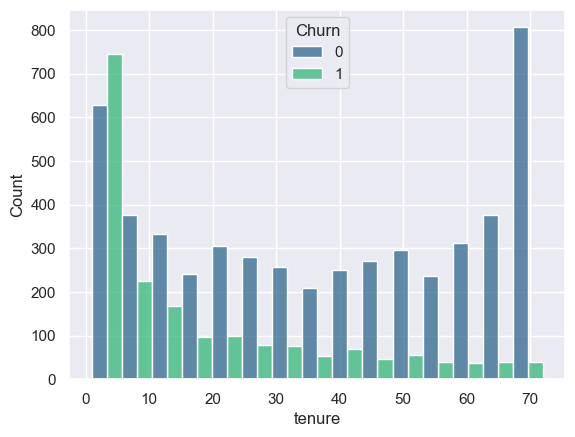

In [138]:
sns.histplot(data=df, x="tenure", hue="Churn", palette="viridis", multiple="dodge");

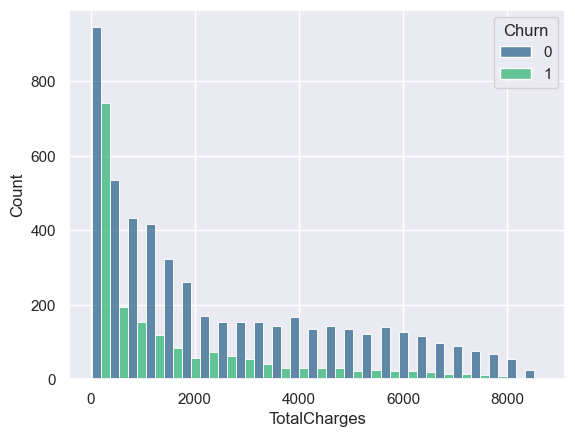

In [139]:
sns.histplot(
    data=df, x="TotalCharges", hue="Churn", palette="viridis", multiple="dodge"
);


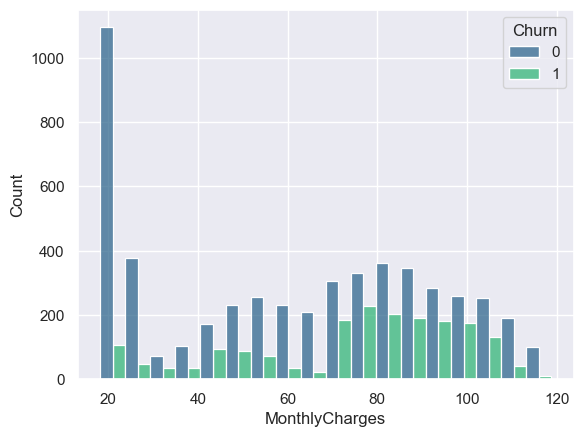

In [140]:
sns.histplot(
    data=df, x="MonthlyCharges", hue="Churn", palette="viridis", multiple="dodge"
);


In [141]:
corr = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr()
corr["Churn"]

tenure           -0.352296
MonthlyCharges    0.193356
TotalCharges     -0.198347
Churn             1.000000
Name: Churn, dtype: float64

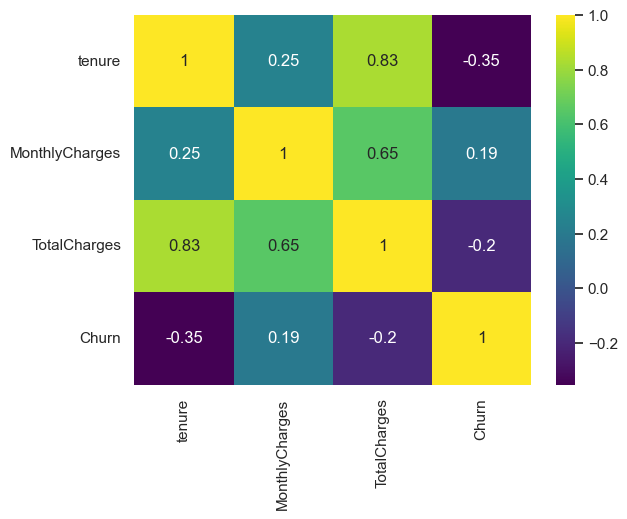

In [142]:
sns.heatmap(corr, annot=True, cmap="viridis");

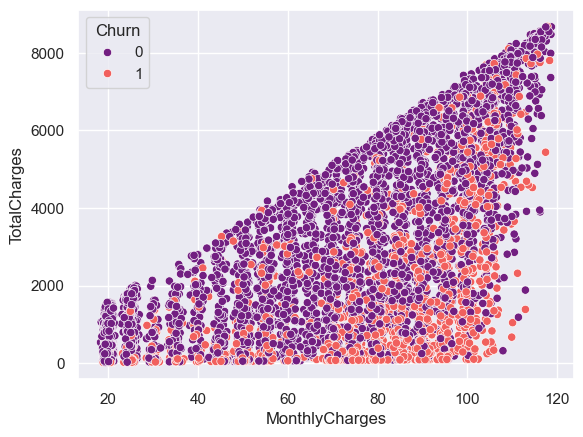

In [143]:
sns.scatterplot(
    data=df, x="MonthlyCharges", y="TotalCharges", hue="Churn", palette="magma"
);

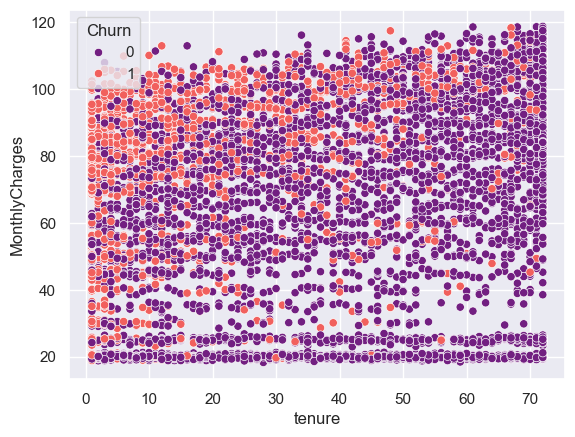

In [144]:
sns.scatterplot(data=df, x="tenure", y="MonthlyCharges", hue="Churn", palette="magma");


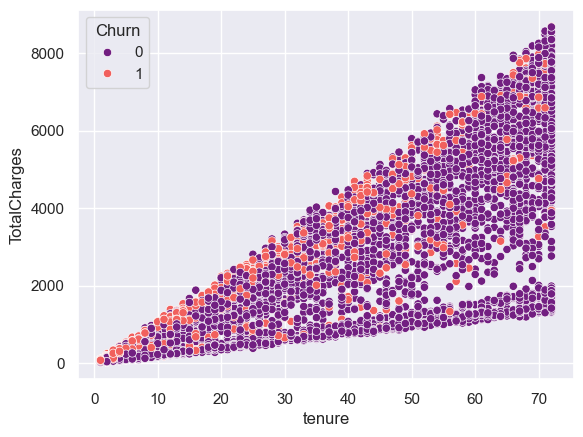

In [145]:
sns.scatterplot(data=df, x="tenure", y="TotalCharges", hue="Churn", palette="magma");


Monthly Charges are a better predictor than TotalCharges, due to tenure's high collinearity with totalcharges, I will drop totalcharges


In [146]:
to_drop.append("TotalCharges")

# Dropping useless features

In [147]:
df = df.drop(to_drop, axis=1)

In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SeniorCitizen             7043 non-null   int64  
 1   tenure                    7043 non-null   int64  
 2   InternetService           7043 non-null   int64  
 3   Contract                  7043 non-null   int64  
 4   PaperlessBilling          7043 non-null   int64  
 5   MonthlyCharges            7043 non-null   float64
 6   Churn                     7043 non-null   int64  
 7   family_score              7043 non-null   int64  
 8   Internet_service_score    7043 non-null   float64
 9   Payment_Electronic_check  7043 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 550.4 KB


In [149]:
df.describe()

,SeniorCitizen,tenure,InternetService,Contract,PaperlessBilling,MonthlyCharges,Churn,family_score,Internet_service_score,Payment_Electronic_check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.372710,1.222916,0.690473,0.592219,64.761692,0.265370,0.782621,1.048985,0.335794
std,0.368612,24.557454,0.778877,0.833755,0.491457,30.090047,0.441561,0.816629,1.540889,0.472301
min,0.000000,1.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000,-1.000000,0.000000
25%,0.000000,9.000000,1.000000,0.000000,0.000000,35.500000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,29.000000,1.000000,0.000000,1.000000,70.350000,0.000000,1.000000,1.000000,0.000000
75%,0.000000,55.000000,2.000000,1.000000,1.000000,89.850000,1.000000,1.000000,2.000000,1.000000
max,1.000000,72.000000,2.000000,2.000000,1.000000,118.750000,1.000000,2.000000,4.000000,1.000000


In [150]:
df.to_csv("data/processed/telco-clean.csv", index=False)